# Подготовка данных и моделирование

Кратко: ноутбук содержит очистку, фичеризацию и базовые модели для дневной капитализации.


In [1]:
# from sktime.transformations.series import impute

import config.config as cfg
from config.columns import dtype_dict_raw, dtype_dict, mults, lines, cat_cols, macro
import pandas as pd
import numpy as np
from dotenv import load_dotenv
load_dotenv(cfg.PROJ_ROOT)

y_name = 'dailycapitalization'
secid = ['secid']
tradedate = ['tradedate']
index = secid + tradedate
pd.set_option("display.max_columns", None)

2026-04-04 15:20:39.987 | INFO     | config.config:<module>:11 - PROJ_ROOT path is: /Users/alexander/PycharmProjects/vmk_thesis


## Подготовка данных


Чтение данных

In [254]:
df = pd.read_csv(
    cfg.PROJ_ROOT / 'data' / 'raw' / 'dataset.csv',
    parse_dates=['tradedate'],
    sep='\t',
    dtype=dtype_dict_raw,
)
df['tradedate'] = pd.to_datetime(df['tradedate'])
df['tradeyear'] = df['tradedate'].dt.year
df.shape

(1871372, 281)

Анализ режимов торгов (boardid)

In [241]:
df['boardid'].unique()

array(['TQBR', 'TQPI', 'SMAL', 'EQDP', 'TQDE', 'EQNE', 'EQBS', 'EQLI',
       'EQNL', 'EQBR', 'EQLV', 'TQNL', 'EQDE', 'TQNE', 'TQBS', 'SPEQ',
       'EQCC', 'TQLV', 'TQDP'], dtype=object)

	•	TQBR — акции, основной стакан (T+2)
	•	TQBS — акции, T+ режим (вариация расчётов, реже используется)
	•	TQPI — режим для квалифицированных инвесторов
	•	TQDE — депозитарные расписки
	•	TQDP — DR / спецрежим
	•	TQNE — адресные сделки в T+
	•	TQLV — низколиквидные бумаги
	•	TQNL — неликвид / ограниченный режим
	•	EQBR — акции (аналог TQBR, но менее ликвидный)
	•	EQNE — адресные сделки
	•	EQBS — режим расчётов
	•	EQLI — листинг / малоликвидные
	•	EQNL — неликвид
	•	EQLV — low volume
	•	EQDE — депозитарные расписки
	•	EQDP — DR / спецрежим
	•	EQCC — клиринговый / спецрежим
	•	SMAL — неполные лоты (odd lots)
	•	SPEQ — negotiated / специальные сделки

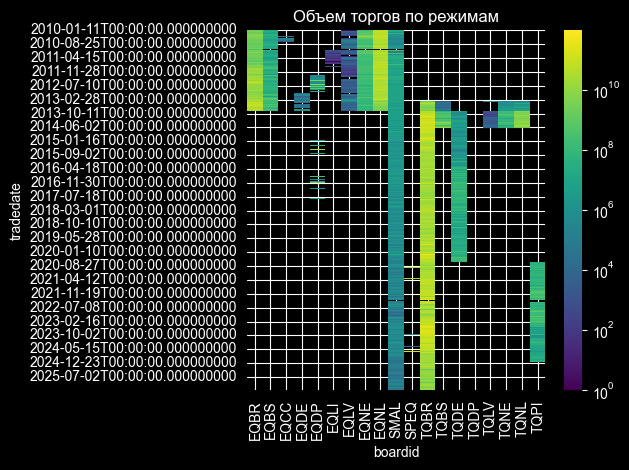

In [155]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

def plot_board_volume_heatmap(df, title):
    pivot = df.pivot_table(index='tradedate', columns='boardid', values='volume', aggfunc='sum')
    sns.heatmap(pivot, cmap="viridis", norm=LogNorm())
    plt.title(title)
    plt.tight_layout()
    plt.show()

plot_board_volume_heatmap(df, "Объем торгов по режимам")

### Предобработка (sklearn pipeline)

In [255]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer, MinMaxScaler, OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sktime.transformations.compose import ColumnEnsembleTransformer, TransformerPipeline
from sktime.transformations.series.impute import Imputer

from src.utils import restore_cap


def filter_boards(df):
    return df[df["boardid"].isin(["TQBR", "EQBR", "TQBS", "EQBS", "TQLV", "EQLV", "TQNL", "EQNL",])].copy()

def drop_additional_issues(df):
    df["base_secid"] = df["secid"].str.replace(r"-0.*$", "", regex=True)
    tmp = pd.concat([
        df.groupby(["base_secid", 'tradedate', 'boardid'])[y_name].sum().rename('sumcap'),
        df.groupby(["base_secid", 'tradedate', 'boardid'])[y_name].max().rename('maxcap'),
        ],
        axis=1
    ).reset_index().sort_values(['base_secid', 'tradedate', 'boardid'])
    tmp['is_issue'] = (abs(tmp['sumcap'] - tmp['maxcap']) > 0).astype(int)
    tmp['issue_cummax'] = tmp.groupby('base_secid')['is_issue'].cummax()
    tmp['issue_cumsum'] = tmp.groupby('base_secid')['is_issue'].cumsum()
    df = tmp.merge(df, on=['base_secid', 'tradedate', 'boardid'], how='left')
    df[y_name] = df['sumcap']
    return df.copy()

def filter_null_cols(df):
    cols = mults + lines
    null_tickers = (
        df.groupby("secid")[cols]
        .apply(lambda g: g.isna().all().all())
        .pipe(lambda s: s[s].index.tolist())
    )
    return df[~df["secid"].isin(null_tickers)].copy()

def categorize(df):
    df["type"] = df["type"].fillna("common_share").astype("category")
    df["sector"] = df["sector"].fillna("other").astype("category")
    return df.copy()

def filter_types(df):
    return df[df["type"].isin(["common_share", "preferred_share"])].copy()

def replace_zeros_with_nan(df):
    return df.replace(0, np.nan).copy()

def gather_secids(df):
    df["inn"] = df["inn"].str.zfill(10)

    def canonical_secid(group):
        min_len = group["secid"].str.len().min()
        candidates = group[group["secid"].str.len() == min_len]
        return candidates["secid"].iloc[0]

    df_common = df[df["type"] == "common_share"]
    df_preferred = df[df["type"] == "preferred_share"]

    inn_to_secid = df_common.groupby("inn").apply(canonical_secid).to_dict()
    df_common["secid"] = df_common["inn"].map(inn_to_secid)

    inn_to_secid = df_preferred.groupby("inn").apply(canonical_secid).to_dict()
    df_preferred["secid"] = df_preferred["inn"].map(inn_to_secid)

    return pd.concat([df_common, df_preferred], ignore_index=True).copy()

def set_index(df):
    return (
        df.sort_values(
            ["secid", "tradedate", "volume", y_name],
            ascending=[True, True, False, False],
        )
        .groupby(index)
        .first()
    ).copy()

def fill_days(df, date_level="tradedate"):
   df = (
        df
        .groupby(level="secid")
        .apply(lambda x: x.droplevel(0).asfreq("D"))
   )
   df['is_vacation'] = df['year'].isna()
   return df

def ffill_bfill(df):
    return df.groupby(level='secid').ffill().groupby(level='secid').bfill()

def target_imputer(df):
    df = df.copy()
    outstanding_shares = df[y_name] / df["close"]
    mask = df[y_name].isna() & df["close"].notna() & outstanding_shares.notna()
    df.loc[mask, y_name] = df.loc[mask, "close"] * outstanding_shares
    df[y_name] = df[y_name].fillna(method='median')
    return df

def add_log_returns(df: pd.DataFrame, col: str, lags: list[int]) -> pd.DataFrame:
    df = df.copy()
    s = df[col].astype(float)

    # лог-доходы только для положительных значений
    s_pos = s.where(s > 0)

    for lag in lags:
        col_name = f"log_returns_{col}_{lag}"
        df[col_name] = (
            s_pos.groupby(level="secid")
            .apply(lambda x: np.log(x).diff(lag))
            .reset_index(level=0, drop=True)
        )
    return df

def replace_target(df: pd.DataFrame) -> pd.DataFrame:
    s = df.groupby(level="secid")[f"log_returns_{y_name}_1"].sum()
    secids_zero = s[s == 0].index

    mask = df.index.get_level_values("secid").isin(secids_zero)
    df.loc[mask, f"log_returns_{y_name}_1"] = df.loc[mask, "log_returns_close_1"]
    cap0 = df.loc[mask, y_name].groupby(level="secid").first().transform(lambda x: x.fillna(x.mean()))
    df.loc[mask, y_name] = restore_cap(df.loc[mask, f"log_returns_{y_name}_1"], cap0)
    return df

def filter_years(df: pd.DataFrame) -> pd.DataFrame:
    return df[df["year"].notna()]

def filter_zero_target(df: pd.DataFrame) -> pd.DataFrame:
    s = df.groupby(level="secid")[f"log_returns_{y_name}_1"].apply(lambda x: np.abs(x).sum())
    secids_keep = s[s >= 1e-9].index
    filtered = df.loc[pd.IndexSlice[secids_keep, :]]
    return filtered


prep_df = Pipeline(
    [
        ("filter_boards", FunctionTransformer(filter_boards, validate=False)),
        ("drop_additional_issues", FunctionTransformer(drop_additional_issues, validate=False)),
        ("categorize", FunctionTransformer(categorize, validate=False)),
        ("filter_types", FunctionTransformer(filter_types, validate=False)),
        ("replace_zeros_with_nan", FunctionTransformer(replace_zeros_with_nan, validate=False)),
        ("gather_secids", FunctionTransformer(gather_secids, validate=False)),
        ("set_index", FunctionTransformer(set_index, validate=False)),
        ("fill_days", FunctionTransformer(fill_days, validate=False)),
        ("ffill_bfill", FunctionTransformer(ffill_bfill, validate=False)),
        ("add_log_returns_cap1", FunctionTransformer(add_log_returns, kw_args={"col": y_name, "lags": [1]}, validate=False)),
        ("add_log_returns_close", FunctionTransformer(add_log_returns, kw_args={"col": "close", "lags": [1]}, validate=False)),
        ("replace_target", FunctionTransformer(replace_target, validate=False)),
        ("add_log_returns_cap5", FunctionTransformer(add_log_returns, kw_args={"col": y_name, "lags": [5]}, validate=False)),
        ("filter_years", FunctionTransformer(filter_years, validate=False)),
        ("filter_zero_target", FunctionTransformer(filter_zero_target, validate=False)),
    ]
)

df = prep_df.fit_transform(df)
df.shape

/var/folders/g4/mpm4njl93p547kbhxbvqlm480000gn/T/ipykernel_6237/2056403266.py:59: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  inn_to_secid = df_common.groupby("inn").apply(canonical_secid).to_dict()
/var/folders/g4/mpm4njl93p547kbhxbvqlm480000gn/T/ipykernel_6237/2056403266.py:60: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_common["secid"] = df_common["inn"].map(inn_to_secid)
/var/folders/g4/mpm4njl93p547kbhxbvqlm480000gn/T/ipykernel_6237/2056403266.py:62:

(1063946, 289)

### Сглаживание

Smoothing annual reports data

In [258]:
from src.steps.smoothing import lowess_smooth

new_cols = {}
for col in [f'log_returns_{y_name}_1'] + mults + lines:
    new_col = 'smoothed_' + col
    new_cols[new_col] = lowess_smooth(df[col])
    print(new_col)
df = pd.concat([df, pd.DataFrame(new_cols, index=df.index)], axis=1)

smoothed_log_returns_dailycapitalization_1
smoothed_capex_revenue_rsbu
smoothed_capex_revenue_msfo
smoothed_capital_rsbu
smoothed_capital_msfo
smoothed_current_ratio_rsbu
smoothed_current_ratio_msfo
smoothed_debt_equity_rsbu
smoothed_debt_equity_msfo
smoothed_debt_ratio_rsbu
smoothed_debt_ratio_msfo
smoothed_debtebitda_rsbu
smoothed_debtebitda_msfo
smoothed_dpr_rsbu
smoothed_dpr_msfo
smoothed_ebitda_margin_rsbu
smoothed_ebitda_margin_msfo
smoothed_ev_ebit_rsbu
smoothed_ev_ebit_msfo
smoothed_evebitda_rsbu
smoothed_evebitda_msfo
smoothed_evs_rsbu
smoothed_evs_msfo
smoothed_gross_margin_rsbu
smoothed_gross_margin_msfo
smoothed_interest_coverage_rsbu
smoothed_interest_coverage_msfo
smoothed_net_margin_rsbu
smoothed_net_margin_msfo
smoothed_net_working_capital_rsbu
smoothed_net_working_capital_msfo
smoothed_netdebt_ebitda_rsbu
smoothed_netdebt_ebitda_msfo
smoothed_operation_margin_rsbu
smoothed_operation_margin_msfo
smoothed_pbv_rsbu
smoothed_pbv_msfo
smoothed_pcf_rsbu
smoothed_pcf_msfo
smo

Add log returns for smoothed data

In [259]:
new_cols = {}
for col in mults + lines:
    new_col = 'smoothed_' + col
    df = add_log_returns(df, new_col, [1])
    print(new_col)
df.shape

smoothed_capex_revenue_rsbu
smoothed_capex_revenue_msfo
smoothed_capital_rsbu
smoothed_capital_msfo
smoothed_current_ratio_rsbu
smoothed_current_ratio_msfo
smoothed_debt_equity_rsbu
smoothed_debt_equity_msfo
smoothed_debt_ratio_rsbu
smoothed_debt_ratio_msfo
smoothed_debtebitda_rsbu
smoothed_debtebitda_msfo
smoothed_dpr_rsbu
smoothed_dpr_msfo
smoothed_ebitda_margin_rsbu
smoothed_ebitda_margin_msfo
smoothed_ev_ebit_rsbu
smoothed_ev_ebit_msfo
smoothed_evebitda_rsbu
smoothed_evebitda_msfo
smoothed_evs_rsbu
smoothed_evs_msfo
smoothed_gross_margin_rsbu
smoothed_gross_margin_msfo
smoothed_interest_coverage_rsbu
smoothed_interest_coverage_msfo
smoothed_net_margin_rsbu
smoothed_net_margin_msfo
smoothed_net_working_capital_rsbu
smoothed_net_working_capital_msfo
smoothed_netdebt_ebitda_rsbu
smoothed_netdebt_ebitda_msfo
smoothed_operation_margin_rsbu
smoothed_operation_margin_msfo
smoothed_pbv_rsbu
smoothed_pbv_msfo
smoothed_pcf_rsbu
smoothed_pcf_msfo
smoothed_pe_rsbu
smoothed_pe_msfo
smoothed_pfc

(1063946, 776)

One-hot encoding for categorical features and scaling for numerical features

In [260]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

desc = df[[col for col in df.columns if col.startswith('smoothed_')]].describe(include='all')
cols_minmax = desc.loc['min'][desc.loc['min'] > -1e-6].index.tolist()
cols_standard = desc.loc['min'][desc.loc['min'] < -1e-6].index.tolist()
preprocess = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
        ('mm', MinMaxScaler(), cols_minmax),
        ('st', StandardScaler(), cols_standard),
    ],
)
df_sc = preprocess.fit_transform(df)
df[preprocess.get_feature_names_out()] = df_sc
df.shape

/var/folders/g4/mpm4njl93p547kbhxbvqlm480000gn/T/ipykernel_6237/3747949882.py:14: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[preprocess.get_feature_names_out()] = df_sc
/var/folders/g4/mpm4njl93p547kbhxbvqlm480000gn/T/ipykernel_6237/3747949882.py:14: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[preprocess.get_feature_names_out()] = df_sc
/var/folders/g4/mpm4njl93p547kbhxbvqlm480000gn/T/ipykernel_6237/3747949882.py:14: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.inse

(1063946, 1033)

In [ ]:
from src.steps.pipelines import build_full_pipeline

pipe = build_full_pipeline()
df = pipe.fit_transform(df)
df.shape

Save processed data

In [261]:
df.to_csv(
    cfg.PROJ_ROOT / 'data' / 'processed' / 'dataset.csv',
    sep='\t',
)

## ЧЕРНОВИК sktime TimeSeriesForestRegressor и Feature Selection

In [1]:
from config.columns import dtype_dict
import config.config as cfg
import pandas as pd
import numpy as np

y_name = 'log_returns_dailycapitalization_1'
secid = ['secid']
tradedate = ['tradedate']
index = secid + tradedate
pd.set_option("display.max_columns", None)

df = pd.read_csv(
    # cfg.PROJ_ROOT / 'data' / 'processed' / 'dataset.csv',
    cfg.PROJ_ROOT / 'data' / 'processed' / 'dataset_smoothed.csv',
    dtype=dtype_dict,
    sep='\t',
    usecols=list(dtype_dict.keys()),
)
df['tradedate'] = pd.to_datetime(df['tradedate'])
df = df[df[y_name].notna()]
df = df.replace([np.inf, -np.inf], np.nan).fillna(0)
df = df.sort_values(index).set_index(index)
df.shape

2026-04-05 10:50:39.106 | INFO     | config.config:<module>:11 - PROJ_ROOT path is: /Users/alexander/PycharmProjects/vmk_thesis


(1063584, 502)

2026-04-04 23:49:33.130 | INFO     | src.forecast.run:run_expanding_cv:32 - Forecast CV start: estimator=GradientBoostingRegressor pooling=global cap_col=dailycapitalization ticker=AFLT
2026-04-04 23:49:33.202 | INFO     | src.forecast.run:run_expanding_cv:46 - Fold 1: split sizes train=291086 test=96094
2026-04-04 23:49:36.574 | INFO     | src.forecast.run:run_expanding_cv:68 - Fold 1: fitting forecaster
2026-04-05 01:10:33.410 | INFO     | src.forecast.run:run_expanding_cv:70 - Fold 1: predicting
2026-04-05 01:10:37.368 | INFO     | src.forecast.run:run_expanding_cv:79 - Fold 1: wmape=0.03755471253631628


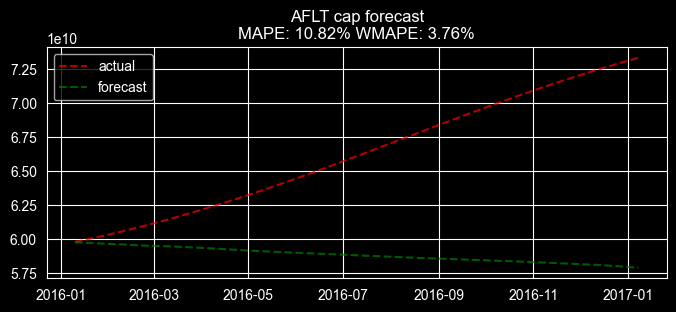

2026-04-05 01:10:37.529 | INFO     | src.forecast.run:run_expanding_cv:46 - Fold 2: split sizes train=387180 test=92885
2026-04-05 01:10:40.348 | INFO     | src.forecast.run:run_expanding_cv:68 - Fold 2: fitting forecaster


KeyboardInterrupt: 

In [2]:
from src.forecast.features import get_feature_importances
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from ngboost import NGBRegressor
from src.forecast import ForecastConfig, prepare_xy, run_expanding_cv

cfg = ForecastConfig(
    y_name="log_returns_dailycapitalization_1",
    # estimator=NGBRegressor(
    #     n_estimators=100,
    #     learning_rate=0.05,
    #     random_state=42,
    # ),
    estimator=GradientBoostingRegressor(n_estimators=200, random_state=42),
    pooling="global",
    ticker='AFLT',
)

y, X = prepare_xy(df, cfg)
result = run_expanding_cv(y, X, cfg)
fi = get_feature_importances(result)
fi.head(20)

2026-04-05 01:37:37.774 | INFO     | src.forecast.run:run_expanding_cv:32 - Forecast CV start: estimator=RandomForestRegressor pooling=global cap_col=dailycapitalization ticker=AFLT
2026-04-05 01:37:37.819 | INFO     | src.forecast.run:run_expanding_cv:46 - Fold 1: split sizes train=291086 test=96094
2026-04-05 01:37:40.987 | INFO     | src.forecast.run:run_expanding_cv:68 - Fold 1: fitting forecaster
2026-04-05 08:48:37.642 | INFO     | src.forecast.run:run_expanding_cv:70 - Fold 1: predicting
2026-04-05 08:48:43.072 | INFO     | src.forecast.run:run_expanding_cv:79 - Fold 1: wmape=0.026735221337887024


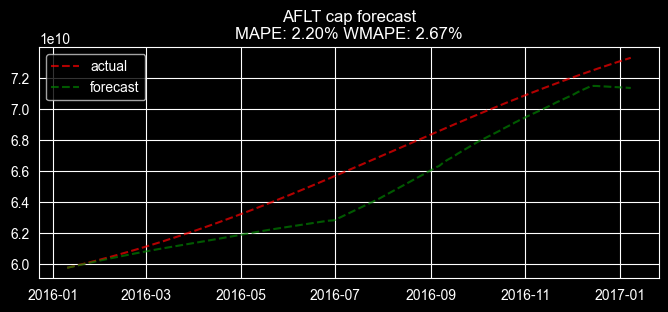

2026-04-05 08:48:43.183 | INFO     | src.forecast.run:run_expanding_cv:46 - Fold 2: split sizes train=387180 test=92885
2026-04-05 08:48:47.636 | INFO     | src.forecast.run:run_expanding_cv:68 - Fold 2: fitting forecaster


In [ ]:
from src.forecast.features import get_feature_importances
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from src.forecast import ForecastConfig, prepare_xy, run_expanding_cv

cfg = ForecastConfig(
    y_name="log_returns_dailycapitalization_1",
    estimator=RandomForestRegressor(n_estimators=200, random_state=42),
    # estimator=GradientBoostingRegressor(n_estimators=200, random_state=42),
    pooling="global",
    ticker='AFLT',
)

y, X = prepare_xy(df, cfg)
result = run_expanding_cv(y, X, cfg)
fi = get_feature_importances(result)
fi.head(20)

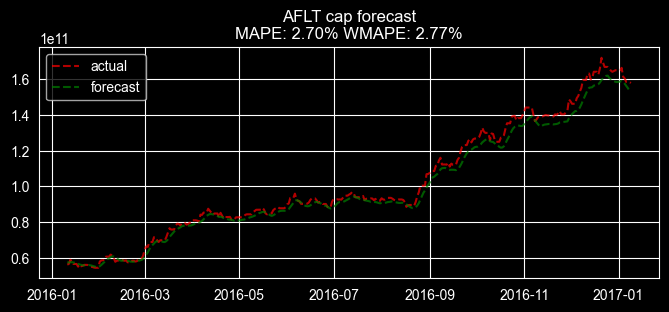

KeyboardInterrupt: 

In [2]:
from src.forecast import mape_by_secid, wmape
from src.utils import restore_cap
# from src.evaluate import mape_by_secid, wmape
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from src.utils import split_multiindex_by_date

from sktime.forecasting.base import ForecastingHorizon
from sktime.forecasting.compose import YfromX
from sktime.split import ExpandingWindowSplitter
from sklearn.ensemble import GradientBoostingRegressor

y, X = df[y_name].to_frame("log_return"), df.drop(columns=[y_name])

reg = GradientBoostingRegressor(n_estimators=100, random_state=42)
forecaster = YfromX(estimator=reg, pooling="global")

n = 365
fh = np.arange(1, n + 1)
cv = ExpandingWindowSplitter(initial_window=n * 5, step_length=n, fh=fh)

scores = []

for fold, (train_idx, test_idx) in enumerate(split_multiindex_by_date(y, cv)):
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]

    common_idx = y_test.index.intersection(X_test.index)
    y_test = y_test.loc[common_idx]
    X_test = X_test.loc[common_idx]

    X_train_m = X_train.drop(columns=["dailycapitalization"])
    X_test_m = X_test.drop(columns=["dailycapitalization"])

    test_dates = y_test.index.get_level_values("tradedate").unique().sort_values()
    needed_dates = set(test_dates)

    secid_ok = (
        X_test_m.reset_index()
        .groupby("secid")["tradedate"]
        .apply(lambda s: set(s) >= needed_dates)
    )
    secids_keep = secid_ok[secid_ok].index

    y_test = y_test.loc[pd.IndexSlice[secids_keep, :]]
    X_test_m = X_test_m.loc[pd.IndexSlice[secids_keep, :]]

    y_train = y_train.loc[pd.IndexSlice[secids_keep, :]]
    X_train_m = X_train_m.loc[pd.IndexSlice[secids_keep, :]]

    cap0 = X_test.loc[pd.IndexSlice[secids_keep, :], "dailycapitalization"].groupby(level="secid").first()

    fh_rel = ForecastingHorizon(np.arange(1, len(test_dates) + 1), is_relative=True, freq="D")

    forecaster.fit(y_train, X_train_m)
    y_pred = forecaster.predict(fh=fh_rel, X=X_test_m)

    cap_y_test = restore_cap(y_test.iloc[:, 0], cap0)
    cap_y_pred = restore_cap(y_pred.iloc[:, 0], cap0)

    mape_secid = mape_by_secid(cap_y_test, cap_y_pred)
    score = wmape(cap_y_test, cap_y_pred, weights=cap_y_test)
    scores.append(score)

    ticker = "AFLT"
    plt.figure(figsize=(8, 3))
    plt.title(f"{ticker} cap forecast\nMAPE: {mape_secid[ticker]*100:.2f}% WMAPE: {score*100:.2f}%")
    plt.plot(cap_y_test.xs(ticker, level="secid"), "r--", alpha=0.7)
    plt.plot(cap_y_pred.xs(ticker, level="secid"), "g--", alpha=0.7)
    plt.legend(["actual", "forecast"])
    plt.show()

np.mean(scores), np.std(scores)

/Users/alexander/PycharmProjects/ngboost/ngboost/distns/normal.py:71: RuntimeWarning: overflow encountered in exp
  self.scale = np.exp(params[1])
/Users/alexander/PycharmProjects/ngboost/ngboost/distns/normal.py:72: RuntimeWarning: overflow encountered in square
  self.var = self.scale**2


[iter 0] loss=-1.5493 val_loss=0.0000 scale=0.1250 norm=0.1106


/Users/alexander/PycharmProjects/ngboost/ngboost/distns/normal.py:72: RuntimeWarning: overflow encountered in square
  self.var = self.scale**2
/Users/alexander/PycharmProjects/ngboost/ngboost/distns/normal.py:71: RuntimeWarning: overflow encountered in exp
  self.scale = np.exp(params[1])
/Users/alexander/PycharmProjects/ngboost/ngboost/distns/normal.py:71: RuntimeWarning: overflow encountered in exp
  self.scale = np.exp(params[1])
/Users/alexander/PycharmProjects/ngboost/ngboost/distns/normal.py:72: RuntimeWarning: overflow encountered in square
  self.var = self.scale**2
/Users/alexander/PycharmProjects/ngboost/ngboost/distns/normal.py:71: RuntimeWarning: overflow encountered in exp
  self.scale = np.exp(params[1])
/Users/alexander/PycharmProjects/ngboost/ngboost/distns/normal.py:72: RuntimeWarning: overflow encountered in square
  self.var = self.scale**2
/Users/alexander/PycharmProjects/ngboost/ngboost/distns/normal.py:72: RuntimeWarning: overflow encountered in square
  self.var

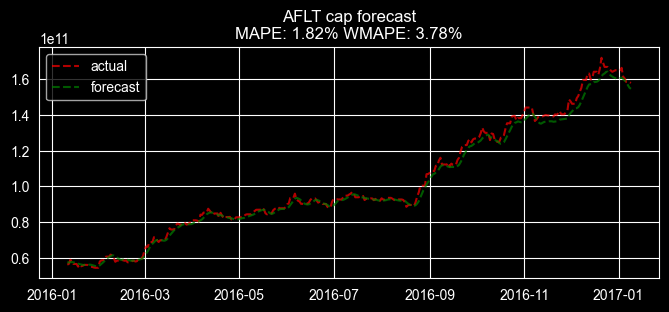

KeyboardInterrupt: 

In [4]:
from src.forecast import mape_by_secid, wmape
from src.utils import restore_cap
# from src.evaluate import mape_by_secid, wmape
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from src.utils import split_multiindex_by_date

from sktime.forecasting.base import ForecastingHorizon
from sktime.forecasting.compose import YfromX
from sktime.split import ExpandingWindowSplitter
from sklearn.ensemble import GradientBoostingRegressor
from ngboost import NGBRegressor
y, X = df[y_name].to_frame("log_return"), df.drop(columns=[y_name])

# reg = GradientBoostingRegressor(n_estimators=100, random_state=42)
reg = NGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42,
)
forecaster = YfromX(estimator=reg, pooling="global")

n = 365
fh = np.arange(1, n + 1)
cv = ExpandingWindowSplitter(initial_window=n * 5, step_length=n, fh=fh)

scores = []

for fold, (train_idx, test_idx) in enumerate(split_multiindex_by_date(y, cv)):
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]

    common_idx = y_test.index.intersection(X_test.index)
    y_test = y_test.loc[common_idx]
    X_test = X_test.loc[common_idx]

    X_train_m = X_train.drop(columns=["dailycapitalization"])
    X_test_m = X_test.drop(columns=["dailycapitalization"])

    test_dates = y_test.index.get_level_values("tradedate").unique().sort_values()
    needed_dates = set(test_dates)

    secid_ok = (
        X_test_m.reset_index()
        .groupby("secid")["tradedate"]
        .apply(lambda s: set(s) >= needed_dates)
    )
    secids_keep = secid_ok[secid_ok].index

    y_test = y_test.loc[pd.IndexSlice[secids_keep, :]]
    X_test_m = X_test_m.loc[pd.IndexSlice[secids_keep, :]]

    y_train = y_train.loc[pd.IndexSlice[secids_keep, :]]
    X_train_m = X_train_m.loc[pd.IndexSlice[secids_keep, :]]

    cap0 = X_test.loc[pd.IndexSlice[secids_keep, :], "dailycapitalization"].groupby(level="secid").first()

    fh_rel = ForecastingHorizon(np.arange(1, len(test_dates) + 1), is_relative=True, freq="D")

    forecaster.fit(y_train, X_train_m)
    y_pred = forecaster.predict(fh=fh_rel, X=X_test_m)

    cap_y_test = restore_cap(y_test.iloc[:, 0], cap0)
    cap_y_pred = restore_cap(y_pred.iloc[:, 0], cap0)

    mape_secid = mape_by_secid(cap_y_test, cap_y_pred)
    score = wmape(cap_y_test, cap_y_pred, weights=cap_y_test)
    scores.append(score)

    ticker = "AFLT"
    plt.figure(figsize=(8, 3))
    plt.title(f"{ticker} cap forecast\nMAPE: {mape_secid[ticker]*100:.2f}% WMAPE: {score*100:.2f}%")
    plt.plot(cap_y_test.xs(ticker, level="secid"), "r--", alpha=0.7)
    plt.plot(cap_y_pred.xs(ticker, level="secid"), "g--", alpha=0.7)
    plt.legend(["actual", "forecast"])
    plt.show()

np.mean(scores), np.std(scores)

In [ ]:
feature_importances: pd.Series = get_feature_importances(forecaster)
feature_importances

In [ ]:
import numpy as np
import pandas as pd
import yfinance as yf

from sktime.forecasting.compose import make_reduction
from sktime.forecasting.model_selection import temporal_train_test_split
from sktime.forecasting.base import ForecastingHorizon
from sktime.regression.interval_based import TimeSeriesForestRegressor

from ngboost import NGBoost
from ngboost.distns import Normal
from ngboost.scores import LogScore

# ---------- 1) Данные: цена акции ----------
ticker = "MSFT"
df = yf.download(ticker, start="2018-01-01", auto_adjust=True, progress=False)

# целевая
y = df["Close"].asfreq("B").ffill()
y.name = "close"

In [ ]:
# ---------- 2) Модель 1: TimeSeriesForestRegressor ----------
tsfr = TimeSeriesForestRegressor(
    n_estimators=200,
    random_state=42,
)

fc_tsfr = make_reduction(
    tsfr,
    strategy="recursive",
    window_length=24,
)

fc_tsfr.fit(y_train)
y_pred_tsfr = fc_tsfr.predict(fh, )

print("TSFR forecast:")
print(y_pred_tsfr.head())


In [ ]:

# ---------- 3) Модель 2: NGBoost ----------
ngb = NGBoost(
    Dist=Normal,
    Score=LogScore,
    n_estimators=500,
    learning_rate=0.01,
    random_state=0,
)

fc_ngb = make_reduction(
    ngb,
    strategy="recursive",
    window_length=24,
)

fc_ngb.fit(y_train)
y_pred_ngb = fc_ngb.predict(fh)

print("NGBoost forecast:")
print(y_pred_ngb.head())

•
DirectTabularRegressionForecaster
•
RecursiveTabularRegressionForecaster
•
MultioutputTabularRegressionForecaster
•
DirRecTabularRegressionForecaster
•
DirectTimeSeriesRegressionForecaster
•
RecursiveTimeSeriesRegressionForecaster
•
MultioutputTimeSeriesRegressionForecaster
•
DirRecTimeSeriesRegressionForecaster
•
DirectReductionForecaster
•
RecursiveReductionForecaster

In [ ]:
from sktime.forecasting.arima import ARIMA

forecaster = ARIMA()

y_pred = forecaster.fit(y, fh=[1, 2]).predict()

In [ ]:
import pandas as pd
import numpy as np
import config.config as cfg
pd.set_option("display.max_columns", None)

https://www.sktime.net/en/stable/api_reference/auto_generated/sktime.regression.interval_based.TimeSeriesForestRegressor.html

	•	Подходит для табличной регрессии временных рядов, когда важно быстрое обучение и интерпретируемость.
	•	Не требует стационарности ряда.